In [35]:
pip install pyarrow fastparquet seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import os
import pandas as pd

EXPORT_DIR = r"D:\256_group_dataset\phase1_outputs"

TRAIN_PATH = os.path.join(EXPORT_DIR, "interactions_model_ready_train.parquet")
VALID_PATH = os.path.join(EXPORT_DIR, "interactions_model_ready_valid.parquet")
TEST_PATH  = os.path.join(EXPORT_DIR, "interactions_model_ready_test.parquet")

print("Train path:", TRAIN_PATH)
print("Valid path:", VALID_PATH)
print("Test path: ", TEST_PATH)

Train path: D:\256_group_dataset\phase1_outputs\interactions_model_ready_train.parquet
Valid path: D:\256_group_dataset\phase1_outputs\interactions_model_ready_valid.parquet
Test path:  D:\256_group_dataset\phase1_outputs\interactions_model_ready_test.parquet


In [3]:
train_df = pd.read_parquet(TRAIN_PATH, engine="fastparquet")
valid_df = pd.read_parquet(VALID_PATH, engine="fastparquet")
test_df  = pd.read_parquet(TEST_PATH,  engine="fastparquet")

In [4]:
# Normalize schema so the rest of the notebook can use consistent names

def normalize_interaction_schema(df):
    df = df.copy()

    # If exported files use original_user_id / original_item_id, rename them
    if "original_user_id" in df.columns and "user_id" not in df.columns:
        df["user_id"] = df["original_user_id"]

    if "original_item_id" in df.columns and "item_id" not in df.columns:
        df["item_id"] = df["original_item_id"]

    return df

train_df = normalize_interaction_schema(train_df)
valid_df = normalize_interaction_schema(valid_df)
test_df  = normalize_interaction_schema(test_df)

In [5]:
# Quick schema / preview check

print("TRAIN COLUMNS:", list(train_df.columns))
print("VALID COLUMNS:", list(valid_df.columns))
print("TEST COLUMNS: ", list(test_df.columns))

display(train_df.head())

TRAIN COLUMNS: ['interaction_id', 'user_idx', 'item_idx', 'rating', 'timestamp', 'split', 'original_user_id', 'original_item_id', 'user_id', 'item_id']
VALID COLUMNS: ['interaction_id', 'user_idx', 'item_idx', 'rating', 'timestamp', 'split', 'original_user_id', 'original_item_id', 'user_id', 'item_id']
TEST COLUMNS:  ['interaction_id', 'user_idx', 'item_idx', 'rating', 'timestamp', 'split', 'original_user_id', 'original_item_id', 'user_id', 'item_id']


,interaction_id,user_idx,item_idx,rating,timestamp,split,original_user_id,original_item_id,user_id,item_id
0,37347498,711617,206723,1.0,2002-07-01,train,Lorraine7,Hotel_Review-g34172-d88311-Reviews-Best_Wester...,Lorraine7,Hotel_Review-g34172-d88311-Reviews-Best_Wester...
1,13529409,1649570,269376,1.0,2002-08-01,train,mzani,Hotel_Review-g60750-d80133-Reviews-Handlery_Ho...,mzani,Hotel_Review-g60750-d80133-Reviews-Handlery_Ho...
2,19927246,713942,208141,5.0,2002-08-01,train,Louisville40204,Hotel_Review-g34439-d145476-Reviews-Sherbrooke...,Louisville40204,Hotel_Review-g34439-d145476-Reviews-Sherbrooke...
3,28220531,343920,30997,4.0,2002-08-01,train,Cerce,Hotel_Review-g153292-d153995-Reviews-Hotel_Bar...,Cerce,Hotel_Review-g153292-d153995-Reviews-Hotel_Bar...
4,1528489,1607657,116123,4.0,2002-09-01,train,mcguillicudy,Hotel_Review-g264369-d148789-Reviews-Lazy_Parr...,mcguillicudy,Hotel_Review-g264369-d148789-Reviews-Lazy_Parr...


In [6]:
# Basic sanity checks to make sure the popularity notebook is using the expected pipeline outputs

required_cols = ["interaction_id", "user_id", "item_id", "rating", "timestamp", "split"]

for name, df in [("train", train_df), ("valid", valid_df), ("test", test_df)]:
    missing = [c for c in required_cols if c not in df.columns]
    print(f"{name} missing columns:", missing)

    print(f"\n{name.upper()} SUMMARY")
    print("rows:", len(df))
    print("unique users:", df["user_id"].nunique())
    print("unique items:", df["item_id"].nunique())
    print("rating min/max:", df["rating"].min(), df["rating"].max())
    print("split values:", df["split"].unique())
    print("timestamp min/max:", df["timestamp"].min(), df["timestamp"].max())
    print("-" * 50)

train missing columns: []

TRAIN SUMMARY
rows: 16064988
unique users: 1927834
unique items: 309395
rating min/max: 1.0 5.0
split values: ['train']
timestamp min/max: 2002-07-01 00:00:00 2019-05-08 00:00:00
--------------------------------------------------
valid missing columns: []

VALID SUMMARY
rows: 1927834
unique users: 1927834
unique items: 253644
rating min/max: 1.0 5.0
split values: ['valid']
timestamp min/max: 2002-10-01 00:00:00 2019-05-11 00:00:00
--------------------------------------------------
test missing columns: []

TEST SUMMARY
rows: 1927834
unique users: 1927834
unique items: 247137
rating min/max: 1.0 5.0
split values: ['test']
timestamp min/max: 2002-10-01 00:00:00 2019-09-20 00:00:00
--------------------------------------------------


In [7]:
# SECTION 2 — Compute train-only item popularity statistics

# We will build the popularity model using TRAIN data only.
# This avoids leakage from validation/test.

train_item_stats = (
    train_df
    .groupby("item_id", as_index=False)
    .agg(
        item_review_count=("rating", "size"),
        item_mean_rating=("rating", "mean")
    )
)

global_mean_rating = train_df["rating"].mean()

print("Global train mean rating:", round(global_mean_rating, 6))
print("Number of items in train stats:", len(train_item_stats))

display(train_item_stats.head())

Global train mean rating: 4.071144
Number of items in train stats: 309395


,item_id,item_review_count,item_mean_rating
0,Hotel_Review-g10006284-d1083311-Reviews-The_Re...,163,4.693252
1,Hotel_Review-g10006284-d151184-Reviews-Club_Me...,734,3.892371
2,Hotel_Review-g10006284-d151225-Reviews-Ports_o...,285,4.035088
3,Hotel_Review-g10006284-d151307-Reviews-The_San...,523,4.292543
4,Hotel_Review-g10006284-d185069-Reviews-Point_G...,106,4.528302


In [8]:
# Choose the smoothing constant m
# Recommendation: median item review count in TRAIN
# Reason:
# - simple and data-driven
# - shrinks low-support items toward the global mean
# - keeps this baseline stable without making it complicated

m = int(train_item_stats["item_review_count"].median())

print("Smoothing constant m (median item review count):", m)

Smoothing constant m (median item review count): 18


In [9]:
# Compute the Bayesian-smoothed popularity score
#
# score_i = (v / (v + m)) * R + (m / (v + m)) * C
#
# where:
# v = item review count in train
# R = item mean rating in train
# C = global train mean rating

train_item_stats["popularity_score"] = (
    (train_item_stats["item_review_count"] / (train_item_stats["item_review_count"] + m)) * train_item_stats["item_mean_rating"]
    + (m / (train_item_stats["item_review_count"] + m)) * global_mean_rating
)

display(train_item_stats.head())

,item_id,item_review_count,item_mean_rating,popularity_score
0,Hotel_Review-g10006284-d1083311-Reviews-The_Re...,163,4.693252,4.631385
1,Hotel_Review-g10006284-d151184-Reviews-Club_Me...,734,3.892371,3.896650
2,Hotel_Review-g10006284-d151225-Reviews-Ports_o...,285,4.035088,4.037230
3,Hotel_Review-g10006284-d151307-Reviews-The_San...,523,4.292543,4.285177
4,Hotel_Review-g10006284-d185069-Reviews-Point_G...,106,4.528302,4.461940


In [10]:
# Create the global popularity ranking
# Highest score first, then more reviews, then higher mean rating, then item_id for stable ordering

popularity_ranking_df = (
    train_item_stats
    .sort_values(
        by=["popularity_score", "item_review_count", "item_mean_rating", "item_id"],
        ascending=[False, False, False, True]
    )
    .reset_index(drop=True)
)

# Add explicit rank column
popularity_ranking_df["pop_rank"] = range(1, len(popularity_ranking_df) + 1)

display(popularity_ranking_df.head(20))

,item_id,item_review_count,item_mean_rating,popularity_score,pop_rank
0,Hotel_Review-g274707-d658737-Reviews-Hotel_Res...,815,4.968098,4.948716,1
1,Hotel_Review-g188671-d1534996-Reviews-Huis_Kon...,215,5.000000,4.928243,2
2,Hotel_Review-g274887-d635259-Reviews-Kapital_I...,287,4.979094,4.925510,3
3,Hotel_Review-g188671-d590867-Reviews-Cote_Cana...,297,4.976431,4.924700,4
4,Hotel_Review-g298564-d1547516-Reviews-Hotel_Mu...,334,4.964072,4.918411,5
5,Hotel_Review-g186612-d213125-Reviews-Friars_Gl...,458,4.949782,4.916556,6
6,Hotel_Review-g293924-d7180030-Reviews-Hanoi_La...,974,4.929158,4.913589,7
7,Hotel_Review-g186370-d2001897-Reviews-Hawkins_...,196,4.989796,4.912526,8
8,Hotel_Review-g471846-d646675-Reviews-Dulini_Lo...,214,4.981308,4.910692,9
9,Hotel_Review-g188675-d2173238-Reviews-Main_Str...,211,4.981043,4.909522,10


In [11]:
# Most-reviewed ranking — same shape as popularity_ranking_df, sorted purely by review count
# Tie-break: higher mean rating, then item_id (stable)

most_reviewed_ranking_df = (
    train_item_stats
    .sort_values(
        by=["item_review_count", "item_mean_rating", "item_id"],
        ascending=[False, False, True]
    )
    .reset_index(drop=True)
)
most_reviewed_ranking_df["pop_rank"] = range(1, len(most_reviewed_ranking_df) + 1)

display(most_reviewed_ranking_df.head(20))

,item_id,item_review_count,item_mean_rating,popularity_score,pop_rank
0,Hotel_Review-g187051-d243420-Reviews-Sofitel_L...,4110,4.251825,4.251037,1
1,Hotel_Review-g293924-d299548-Reviews-Sofitel_L...,3555,4.748523,4.745111,2
2,Hotel_Review-g154998-d278011-Reviews-Embassy_S...,3454,4.005211,4.005553,3
3,Hotel_Review-g187069-d210728-Reviews-Radisson_...,3297,4.165302,4.164791,4
4,Hotel_Review-g294265-d302294-Reviews-Pan_Pacif...,3292,4.533718,4.531203,5
5,Hotel_Review-g294265-d301573-Reviews-Swissotel...,3238,4.124768,4.124472,6
6,Hotel_Review-g60763-d93450-Reviews-Grand_Hyatt...,3177,3.700346,3.702435,7
7,Hotel_Review-g35805-d87617-Reviews-Hyatt_Regen...,3165,3.968720,3.969300,8
8,Hotel_Review-g188590-d1946024-Reviews-DoubleTr...,2976,4.252688,4.251597,9
9,Hotel_Review-g664891-d657141-Reviews-The_Venet...,2890,4.335986,4.334347,10


In [12]:
# Quick sanity checks

print("Popularity ranking size:", len(popularity_ranking_df))
print("Any missing scores?:", popularity_ranking_df["popularity_score"].isna().sum())
print("Any missing item IDs?:", popularity_ranking_df["item_id"].isna().sum())
print("Score range:",
      round(popularity_ranking_df["popularity_score"].min(), 6),
      "to",
      round(popularity_ranking_df["popularity_score"].max(), 6))

Popularity ranking size: 309395
Any missing scores?: 0
Any missing item IDs?: 0
Score range: 1.872657 to 4.948716


In [13]:
# Optional: inspect the most popular items
# This helps verify that the ranking looks reasonable before generating recommendations

top_popular_items_df = popularity_ranking_df.head(20).copy()
display(top_popular_items_df)

,item_id,item_review_count,item_mean_rating,popularity_score,pop_rank
0,Hotel_Review-g274707-d658737-Reviews-Hotel_Res...,815,4.968098,4.948716,1
1,Hotel_Review-g188671-d1534996-Reviews-Huis_Kon...,215,5.000000,4.928243,2
2,Hotel_Review-g274887-d635259-Reviews-Kapital_I...,287,4.979094,4.925510,3
3,Hotel_Review-g188671-d590867-Reviews-Cote_Cana...,297,4.976431,4.924700,4
4,Hotel_Review-g298564-d1547516-Reviews-Hotel_Mu...,334,4.964072,4.918411,5
5,Hotel_Review-g186612-d213125-Reviews-Friars_Gl...,458,4.949782,4.916556,6
6,Hotel_Review-g293924-d7180030-Reviews-Hanoi_La...,974,4.929158,4.913589,7
7,Hotel_Review-g186370-d2001897-Reviews-Hawkins_...,196,4.989796,4.912526,8
8,Hotel_Review-g471846-d646675-Reviews-Dulini_Lo...,214,4.981308,4.910692,9
9,Hotel_Review-g188675-d2173238-Reviews-Main_Str...,211,4.981043,4.909522,10


In [14]:
# SECTION 3 — Build user history sets and recommendation helper functions

# For validation:
#   filter out items seen in TRAIN
#
# For test:
#   filter out items seen in TRAIN + VALID
#
# This matches your leave-last-out split design:
# - valid predicts the next item after train
# - test predicts the next item after train + valid

train_seen_by_user = train_df.groupby("user_id")["item_id"].agg(set).to_dict()

train_valid_df = pd.concat([train_df, valid_df], ignore_index=True)
train_valid_seen_by_user = train_valid_df.groupby("user_id")["item_id"].agg(set).to_dict()

print("Users with train history:", len(train_seen_by_user))
print("Users with train+valid history:", len(train_valid_seen_by_user))

Users with train history: 1927834
Users with train+valid history: 1927834


In [15]:
# Convert the global ranking to a Python list for fast recommendation generation

global_ranked_items = popularity_ranking_df["item_id"].tolist()

print("Number of ranked items:", len(global_ranked_items))
print("Top 10 globally ranked items:")
print(global_ranked_items[:10])

Number of ranked items: 309395
Top 10 globally ranked items:
['Hotel_Review-g274707-d658737-Reviews-Hotel_Residence_Agnes-Prague_Bohemia.html', 'Hotel_Review-g188671-d1534996-Reviews-Huis_Koning-Bruges_West_Flanders_Province.html', 'Hotel_Review-g274887-d635259-Reviews-Kapital_Inn-Budapest_Central_Hungary.html', 'Hotel_Review-g188671-d590867-Reviews-Cote_Canal-Bruges_West_Flanders_Province.html', 'Hotel_Review-g298564-d1547516-Reviews-Hotel_Mume-Kyoto_Kyoto_Prefecture_Kinki.html', 'Hotel_Review-g186612-d213125-Reviews-Friars_Glen-Killarney_County_Kerry.html', 'Hotel_Review-g293924-d7180030-Reviews-Hanoi_La_Siesta_Hotel_Spa-Hanoi.html', 'Hotel_Review-g186370-d2001897-Reviews-Hawkins_of_Bath-Bath_Somerset_England.html', 'Hotel_Review-g471846-d646675-Reviews-Dulini_Lodge-Sabi_Sand_Game_Reserve_Kruger_National_Park.html', 'Hotel_Review-g188675-d2173238-Reviews-Main_Street_Boutique_Hotel-Ieper_Ypres_West_Flanders_Province.html']


In [16]:
# Parallel item list for the most-reviewed model
# (global_ranked_items stays as-is and still represents the top-rated Bayesian model)

global_ranked_items_by_reviews = most_reviewed_ranking_df["item_id"].tolist()

print("Top 10 by Bayesian popularity score (top-rated):")
print(global_ranked_items[:10])
print("\nTop 10 by review count (most-reviewed):")
print(global_ranked_items_by_reviews[:10])

Top 10 by Bayesian popularity score (top-rated):
['Hotel_Review-g274707-d658737-Reviews-Hotel_Residence_Agnes-Prague_Bohemia.html', 'Hotel_Review-g188671-d1534996-Reviews-Huis_Koning-Bruges_West_Flanders_Province.html', 'Hotel_Review-g274887-d635259-Reviews-Kapital_Inn-Budapest_Central_Hungary.html', 'Hotel_Review-g188671-d590867-Reviews-Cote_Canal-Bruges_West_Flanders_Province.html', 'Hotel_Review-g298564-d1547516-Reviews-Hotel_Mume-Kyoto_Kyoto_Prefecture_Kinki.html', 'Hotel_Review-g186612-d213125-Reviews-Friars_Glen-Killarney_County_Kerry.html', 'Hotel_Review-g293924-d7180030-Reviews-Hanoi_La_Siesta_Hotel_Spa-Hanoi.html', 'Hotel_Review-g186370-d2001897-Reviews-Hawkins_of_Bath-Bath_Somerset_England.html', 'Hotel_Review-g471846-d646675-Reviews-Dulini_Lodge-Sabi_Sand_Game_Reserve_Kruger_National_Park.html', 'Hotel_Review-g188675-d2173238-Reviews-Main_Street_Boutique_Hotel-Ieper_Ypres_West_Flanders_Province.html']

Top 10 by review count (most-reviewed):
['Hotel_Review-g187051-d243420-Re

In [17]:
# Recommendation helper:
# returns the top-K globally popular items that the user has NOT already seen

def recommend_top_k_popular(user_id, seen_items_by_user, ranked_items, k=10):
    seen = seen_items_by_user.get(user_id, set())
    
    recs = []
    for item_id in ranked_items:
        if item_id not in seen:
            recs.append(item_id)
        if len(recs) >= k:
            break
    
    return recs

In [18]:
# Build ground-truth lookup tables
# Because your split is leave-last-out, each user should have exactly one target item in valid and one in test.

valid_target_by_user = dict(zip(valid_df["user_id"], valid_df["item_id"]))
test_target_by_user  = dict(zip(test_df["user_id"], test_df["item_id"]))

print("Validation users:", len(valid_target_by_user))
print("Test users:", len(test_target_by_user))

Validation users: 1927834
Test users: 1927834


In [19]:
# Preview top-10 recs for sample users — both models side-by-side

sample_valid_users = list(valid_target_by_user.keys())[:5]

preview_rows = []
for user_id in sample_valid_users:
    recs_top_rated = recommend_top_k_popular(
        user_id, train_seen_by_user, global_ranked_items, k=10
    )
    recs_most_reviewed = recommend_top_k_popular(
        user_id, train_seen_by_user, global_ranked_items_by_reviews, k=10
    )
    preview_rows.append({
        "user_id": user_id,
        "true_valid_item": valid_target_by_user[user_id],
        "top_rated_recs": recs_top_rated,
        "most_reviewed_recs": recs_most_reviewed,
    })

preview_valid_recs_df = pd.DataFrame(preview_rows)
display(preview_valid_recs_df)

,user_id,true_valid_item,top_rated_recs,most_reviewed_recs
0,Navigate26266,Hotel_Review-g33857-d80762-Reviews-Days_Inn_by...,[Hotel_Review-g274707-d658737-Reviews-Hotel_Re...,[Hotel_Review-g187051-d243420-Reviews-Sofitel_...
1,LightPacker957,Hotel_Review-g188644-d206688-Reviews-Radisson_...,[Hotel_Review-g274707-d658737-Reviews-Hotel_Re...,[Hotel_Review-g187051-d243420-Reviews-Sofitel_...
2,GrandTour19809,Hotel_Review-g194863-d239260-Reviews-Villa_Ros...,[Hotel_Review-g274707-d658737-Reviews-Hotel_Re...,[Hotel_Review-g187051-d243420-Reviews-Sofitel_...
3,Storyteller17290,Hotel_Review-g187870-d235821-Reviews-Pensione_...,[Hotel_Review-g274707-d658737-Reviews-Hotel_Re...,[Hotel_Review-g187051-d243420-Reviews-Sofitel_...
4,GoPlaces25384,Hotel_Review-g150797-d226263-Reviews-Hotel_Jac...,[Hotel_Review-g274707-d658737-Reviews-Hotel_Re...,[Hotel_Review-g187051-d243420-Reviews-Sofitel_...


In [20]:
# Optional: verify none of the recommended items are already in the user's seen history

def count_seen_item_leaks(users, targets, seen_items_by_user, ranked_items, k=10):
    leaks = 0
    for user_id in users:
        recs = recommend_top_k_popular(user_id, seen_items_by_user, ranked_items, k=k)
        seen = seen_items_by_user.get(user_id, set())
        if any(item in seen for item in recs):
            leaks += 1
    return leaks

valid_leaks = count_seen_item_leaks(
    users=sample_valid_users,
    targets=valid_target_by_user,
    seen_items_by_user=train_seen_by_user,
    ranked_items=global_ranked_items,
    k=10
)

print("Recommendation leaks in preview users:", valid_leaks)

Recommendation leaks in preview users: 0


In [21]:
# SECTION 4 — Evaluate the popularity baseline on the VALIDATION split
#
# Metrics:
# - Hit@K: did the true item appear in the top-K recommendations?
# - NDCG@K: gives more credit when the true item appears higher in the ranking
#
# Because each user has exactly one held-out validation item, these are natural ranking metrics.

import math

In [22]:
# Metric helpers

import math

def hit_at_k(recommended_items, true_item):
    return 1.0 if true_item in recommended_items else 0.0

def ndcg_at_k(recommended_items, true_item):
    if true_item not in recommended_items:
        return 0.0
    rank_position = recommended_items.index(true_item) + 1
    return 1.0 / math.log2(rank_position + 1)

def precision_at_k(recommended_items, true_item, k):
    # With a single held-out item: 1/K if hit, 0 otherwise
    return (1.0 / k) if true_item in recommended_items else 0.0

In [23]:
# Negative-sampling evaluator: 1 true held-out item + 100 random negatives per user.
# Evaluates multiple models in a single pass so they share the same per-user negatives.

import numpy as np

def evaluate_models_with_negatives(
    target_by_user,
    seen_items_by_user,
    score_lookups,          # dict {model_name: {item_id: score}}
    candidate_pool,         # array of item_ids that have train scores
    k_values=(5, 10, 20),
    n_negatives=100,
    seed=42,
    fallback_score=0.0,
):
    rng = np.random.default_rng(seed)
    pool = np.asarray(candidate_pool)
    pool_size = len(pool)

    per_hits = {(m, k): 0   for m in score_lookups for k in k_values}
    per_ndcg = {(m, k): 0.0 for m in score_lookups for k in k_values}
    n_users = 0

    for user_id, true_item in target_by_user.items():
        seen = seen_items_by_user.get(user_id, set())
        forbidden = seen | {true_item}

        # Sample 100 unique negatives, oversampling to handle rejections
        negatives = []
        chosen = set()
        attempts = 0
        while len(negatives) < n_negatives and attempts < 8:
            need = n_negatives - len(negatives)
            idx = rng.integers(0, pool_size, size=need * 2 + 50)
            for i in idx:
                item = pool[i]
                if item in forbidden or item in chosen:
                    continue
                chosen.add(item)
                negatives.append(item)
                if len(negatives) >= n_negatives:
                    break
            attempts += 1
        if len(negatives) < n_negatives:
            continue  # extremely rare

        # Rank true_item among the 101 candidates for each model
        for model_name, lookup in score_lookups.items():
            true_score = lookup.get(true_item, fallback_score)
            neg_scores = np.fromiter(
                (lookup.get(n, fallback_score) for n in negatives),
                dtype=np.float64,
                count=n_negatives,
            )
            n_better = int((neg_scores > true_score).sum())
            n_tied   = int((neg_scores == true_score).sum())
            # Random tie-break: place true uniformly within its tie group
            tie_offset = int(rng.integers(0, n_tied + 1)) if n_tied > 0 else 0
            rank_position = 1 + n_better + tie_offset

            for k in k_values:
                if rank_position <= k:
                    per_hits[(model_name, k)] += 1
                    per_ndcg[(model_name, k)] += 1.0 / np.log2(rank_position + 1)

        n_users += 1

    rows = []
    for model_name in score_lookups:
        for k in k_values:
            rows.append({
                "model": model_name,
                "k": k,
                "n_users_evaluated": n_users,
                "Hit@K":  per_hits[(model_name, k)] / n_users if n_users else 0.0,
                "NDCG@K": per_ndcg[(model_name, k)] / n_users if n_users else 0.0,
            })
    return pd.DataFrame(rows)


# Score lookups for both models — built once and reused for valid + test
score_lookup_top_rated     = dict(zip(train_item_stats["item_id"], train_item_stats["popularity_score"]))
score_lookup_most_reviewed = dict(zip(train_item_stats["item_id"], train_item_stats["item_review_count"].astype(float)))

SCORE_LOOKUPS  = {
    "top_rated_bayesian": score_lookup_top_rated,
    "most_reviewed":      score_lookup_most_reviewed,
}
CANDIDATE_POOL = train_item_stats["item_id"].values

print("Candidate pool size:", len(CANDIDATE_POOL))

Candidate pool size: 309395


In [24]:
# Validation evaluation — both models, K=[5,10,20], 100 random negatives per user

K_VALUES = (5, 10, 20)

valid_multi_k_summary_df = evaluate_models_with_negatives(
    target_by_user     = valid_target_by_user,
    seen_items_by_user = train_seen_by_user,
    score_lookups      = SCORE_LOOKUPS,
    candidate_pool     = CANDIDATE_POOL,
    k_values           = K_VALUES,
    n_negatives        = 100,
    seed               = 42,
)

display(valid_multi_k_summary_df)

,model,k,n_users_evaluated,Hit@K,NDCG@K
0,top_rated_bayesian,5,1927834,0.112099,0.069063
1,top_rated_bayesian,10,1927834,0.199615,0.097101
2,top_rated_bayesian,20,1927834,0.329782,0.129829
3,most_reviewed,5,1927834,0.372148,0.263345
4,most_reviewed,10,1927834,0.509659,0.307660
5,most_reviewed,20,1927834,0.671048,0.348392


In [25]:
# RMSE evaluation — rating prediction perspective
# For the popularity baseline, the "predicted rating" for any item is its Bayesian smoothed score.
# For items unseen in training, we fall back to the global mean.
#
# This evaluates a fundamentally different question than ranking metrics:
# "How close is our predicted rating to the actual rating?"

import numpy as np

# Build a lookup from item_id to popularity score
item_score_lookup = dict(zip(
    train_item_stats["item_id"],
    train_item_stats["popularity_score"]
))

def compute_rmse(eval_df, item_score_lookup, global_mean):
    predicted = eval_df["item_id"].map(item_score_lookup).fillna(global_mean)
    actual = eval_df["rating"]
    rmse = np.sqrt(((predicted - actual) ** 2).mean())
    mae = (predicted - actual).abs().mean()
    n_unseen = eval_df["item_id"].map(item_score_lookup).isna().sum()
    return rmse, mae, n_unseen

valid_rmse, valid_mae, valid_unseen = compute_rmse(valid_df, item_score_lookup, global_mean_rating)
test_rmse, test_mae, test_unseen = compute_rmse(test_df, item_score_lookup, global_mean_rating)

rating_pred_df = pd.DataFrame([
    {"split": "valid", "RMSE": round(valid_rmse, 6), "MAE": round(valid_mae, 6),
     "n_evaluated": len(valid_df), "n_unseen_items_fallback": valid_unseen},
    {"split": "test", "RMSE": round(test_rmse, 6), "MAE": round(test_mae, 6),
     "n_evaluated": len(test_df), "n_unseen_items_fallback": test_unseen},
])

print("Rating prediction metrics (predicted = Bayesian avg, fallback = global mean):")
display(rating_pred_df)

Rating prediction metrics (predicted = Bayesian avg, fallback = global mean):


,split,RMSE,MAE,n_evaluated,n_unseen_items_fallback
0,valid,0.934757,0.725877,1927834,997
1,test,0.966656,0.750443,1927834,2458


In [27]:
# Test evaluation — both models, K=[5,10,20], 100 random negatives per user
# Uses train+valid history to filter seen items (matches your existing protocol)

test_multi_k_summary_df = evaluate_models_with_negatives(
    target_by_user     = test_target_by_user,
    seen_items_by_user = train_valid_seen_by_user,
    score_lookups      = SCORE_LOOKUPS,
    candidate_pool     = CANDIDATE_POOL,
    k_values           = K_VALUES,
    n_negatives        = 100,
    seed               = 42,
)

display(test_multi_k_summary_df)

,model,k,n_users_evaluated,Hit@K,NDCG@K
0,top_rated_bayesian,5,1927834,0.113770,0.069974
1,top_rated_bayesian,10,1927834,0.203081,0.098585
2,top_rated_bayesian,20,1927834,0.336871,0.132226
3,most_reviewed,5,1927834,0.383207,0.272944
4,most_reviewed,10,1927834,0.516176,0.315826
5,most_reviewed,20,1927834,0.667123,0.353951


In [28]:
# FINAL SUMMARY — Popularity Baselines (both models)

print("=" * 70)
print("POPULARITY BASELINES — COMPLETE EVALUATION SUMMARY")
print("=" * 70)
print(f"\nProtocol: 1 held-out item + 100 random negatives per user (101 candidates)")
print(f"Same negatives reused across both models for fair comparison")
print(f"Smoothing constant m = {m} (median train item review count)")
print(f"Global mean train rating C = {global_mean_rating:.4f}")
print(f"Items in candidate pool: {len(CANDIDATE_POOL):,}")

print("\n" + "─" * 70)
print("RANKING METRICS (Hit@K, NDCG@K — 100 random negatives)")
print("─" * 70)

ranking_summary = pd.concat(
    [
        valid_multi_k_summary_df.assign(split="valid"),
        test_multi_k_summary_df.assign(split="test"),
    ],
    ignore_index=True,
)[["split", "model", "k", "n_users_evaluated", "Hit@K", "NDCG@K"]] \
 .sort_values(["model", "split", "k"]).reset_index(drop=True)

ranking_display = ranking_summary.copy()
for col in ["Hit@K", "NDCG@K"]:
    ranking_display[col] = ranking_display[col].map(lambda x: f"{x:.6f}")
ranking_display["n_users_evaluated"] = ranking_display["n_users_evaluated"].map(lambda x: f"{x:,}")

display(ranking_display)

print("\n" + "─" * 70)
print("RATING PREDICTION METRICS (RMSE / MAE — unchanged)")
print("─" * 70)
display(rating_pred_df)

POPULARITY BASELINES — COMPLETE EVALUATION SUMMARY

Protocol: 1 held-out item + 100 random negatives per user (101 candidates)
Same negatives reused across both models for fair comparison
Smoothing constant m = 18 (median train item review count)
Global mean train rating C = 4.0711
Items in candidate pool: 309,395

──────────────────────────────────────────────────────────────────────
RANKING METRICS (Hit@K, NDCG@K — 100 random negatives)
──────────────────────────────────────────────────────────────────────


,split,model,k,n_users_evaluated,Hit@K,NDCG@K
0,test,most_reviewed,5,"1,927,834",0.383207,0.272944
1,test,most_reviewed,10,"1,927,834",0.516176,0.315826
2,test,most_reviewed,20,"1,927,834",0.667123,0.353951
3,valid,most_reviewed,5,"1,927,834",0.372148,0.263345
4,valid,most_reviewed,10,"1,927,834",0.509659,0.307660
5,valid,most_reviewed,20,"1,927,834",0.671048,0.348392
6,test,top_rated_bayesian,5,"1,927,834",0.113770,0.069974
7,test,top_rated_bayesian,10,"1,927,834",0.203081,0.098585
8,test,top_rated_bayesian,20,"1,927,834",0.336871,0.132226
9,valid,top_rated_bayesian,5,"1,927,834",0.112099,0.069063



──────────────────────────────────────────────────────────────────────
RATING PREDICTION METRICS (RMSE / MAE — unchanged)
──────────────────────────────────────────────────────────────────────


,split,RMSE,MAE,n_evaluated,n_unseen_items_fallback
0,valid,0.934757,0.725877,1927834,997
1,test,0.966656,0.750443,1927834,2458


In [29]:
# Side-by-side: model × split × K

split_comparison_df = pd.concat(
    [
        valid_multi_k_summary_df.assign(split_name="valid"),
        test_multi_k_summary_df.assign(split_name="test"),
    ],
    ignore_index=True,
)[["split_name", "model", "k", "n_users_evaluated", "Hit@K", "NDCG@K"]] \
 .sort_values(["k", "split_name", "model"]).reset_index(drop=True)

display(split_comparison_df)

,split_name,model,k,n_users_evaluated,Hit@K,NDCG@K
0,test,most_reviewed,5,1927834,0.383207,0.272944
1,test,top_rated_bayesian,5,1927834,0.113770,0.069974
2,valid,most_reviewed,5,1927834,0.372148,0.263345
3,valid,top_rated_bayesian,5,1927834,0.112099,0.069063
4,test,most_reviewed,10,1927834,0.516176,0.315826
5,test,top_rated_bayesian,10,1927834,0.203081,0.098585
6,valid,most_reviewed,10,1927834,0.509659,0.307660
7,valid,top_rated_bayesian,10,1927834,0.199615,0.097101
8,test,most_reviewed,20,1927834,0.667123,0.353951
9,test,top_rated_bayesian,20,1927834,0.336871,0.132226


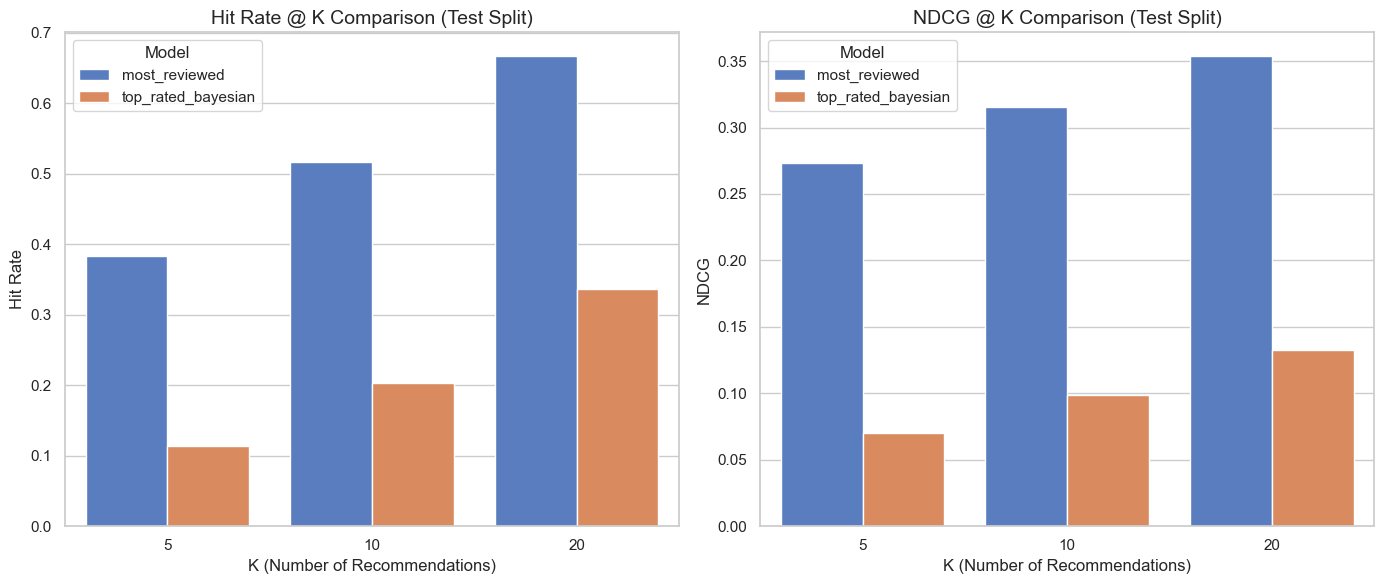

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filter the dataframe to only include the 'test' split
plot_df = split_comparison_df[split_comparison_df['split_name'] == 'test'].copy()

# Set up a 1x2 grid of plots
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Set a nice style
sns.set_theme(style="whitegrid")

# --- 1. Hit@K Bar Chart ---
sns.barplot(
    data=plot_df, 
    x='k', 
    y='Hit@K', 
    hue='model', 
    ax=axes[0],
    palette='muted'
)
axes[0].set_title('Hit Rate @ K Comparison (Test Split)', fontsize=14)
axes[0].set_xlabel('K (Number of Recommendations)', fontsize=12)
axes[0].set_ylabel('Hit Rate', fontsize=12)
axes[0].legend(title='Model')

# --- 2. NDCG@K Bar Chart ---
sns.barplot(
    data=plot_df, 
    x='k', 
    y='NDCG@K', 
    hue='model', 
    ax=axes[1],
    palette='muted'
)
axes[1].set_title('NDCG @ K Comparison (Test Split)', fontsize=14)
axes[1].set_xlabel('K (Number of Recommendations)', fontsize=12)
axes[1].set_ylabel('NDCG', fontsize=12)
axes[1].legend(title='Model')

# Adjust layout and display
plt.tight_layout()
plt.show()

In [ ]:
# SECTION 6 — Final baseline summary and reusable inference helper
#
# This section:
# 1) creates one compact summary table for the popularity baseline
# 2) saves a small config/metadata file
# 3) provides a simple function you can reuse later to get recommendations for any user

import json

In [30]:
final_baseline_summary_df = pd.concat(
    [
        valid_multi_k_summary_df.assign(split_name="valid"),
        test_multi_k_summary_df.assign(split_name="test"),
    ],
    ignore_index=True,
)[["split_name", "model", "k", "n_users_evaluated", "Hit@K", "NDCG@K"]] \
 .sort_values(["model", "split_name", "k"]).reset_index(drop=True)

display(final_baseline_summary_df)

,split_name,model,k,n_users_evaluated,Hit@K,NDCG@K
0,test,most_reviewed,5,1927834,0.383207,0.272944
1,test,most_reviewed,10,1927834,0.516176,0.315826
2,test,most_reviewed,20,1927834,0.667123,0.353951
3,valid,most_reviewed,5,1927834,0.372148,0.263345
4,valid,most_reviewed,10,1927834,0.509659,0.307660
5,valid,most_reviewed,20,1927834,0.671048,0.348392
6,test,top_rated_bayesian,5,1927834,0.113770,0.069974
7,test,top_rated_bayesian,10,1927834,0.203081,0.098585
8,test,top_rated_bayesian,20,1927834,0.336871,0.132226
9,valid,top_rated_bayesian,5,1927834,0.112099,0.069063


In [31]:
# Save a small baseline config so the setup is easy to document later
import json
popularity_baseline_config = {
    "model_name": "smoothed_popularity_baseline",
    "train_file": os.path.basename(TRAIN_PATH),
    "valid_file": os.path.basename(VALID_PATH),
    "test_file": os.path.basename(TEST_PATH),
    "score_definition": "bayesian_smoothed_mean_rating",
    "score_formula": "score_i = (v/(v+m))*R + (m/(v+m))*C",
    "v_definition": "item_review_count_in_train",
    "R_definition": "item_mean_rating_in_train",
    "C_definition": "global_mean_rating_in_train",
    "m_definition": "median_item_review_count_in_train",
    "m_value": int(m),
    "global_mean_rating": float(global_mean_rating),
    "ranking_type": "global_non_personalized_item_ranking",
    "valid_seen_filter": "exclude items seen in train",
    "test_seen_filter": "exclude items seen in train+valid",
    "metrics": ["Hit@K", "NDCG@K"],
    "k_values_evaluated": [5, 10, 20]
}

config_path = os.path.join(EXPORT_DIR, "popularity_baseline_config.json")
with open(config_path, "w", encoding="utf-8") as f:
    json.dump(popularity_baseline_config, f, indent=2)

print("Saved config to:", config_path)

Saved config to: D:\256_group_dataset\phase1_outputs\popularity_baseline_config.json


In [32]:
# Reusable helper for getting recommendations for a single user
#
# split_name='valid'  -> excludes TRAIN history
# split_name='test'   -> excludes TRAIN + VALID history

def get_popularity_recommendations(user_id, split_name="test", k=10):
    if split_name == "valid":
        seen_items = train_seen_by_user
    elif split_name == "test":
        seen_items = train_valid_seen_by_user
    else:
        raise ValueError("split_name must be 'valid' or 'test'")
    
    recs = recommend_top_k_popular(
        user_id=user_id,
        seen_items_by_user=seen_items,
        ranked_items=global_ranked_items,
        k=k
    )
    
    rec_df = popularity_ranking_df[
        popularity_ranking_df["item_id"].isin(recs)
    ][["item_id", "pop_rank", "item_review_count", "item_mean_rating", "popularity_score"]].copy()
    
    rec_df["recommendation_order"] = range(1, len(rec_df) + 1)
    rec_df = rec_df.sort_values("recommendation_order").reset_index(drop=True)
    
    return rec_df

In [33]:
# Example: top-10 recs for one valid and one test user — both models side-by-side

def get_recommendations_both_models(user_id, split_name="test", k=10):
    if split_name == "valid":
        seen_items = train_seen_by_user
    elif split_name == "test":
        seen_items = train_valid_seen_by_user
    else:
        raise ValueError("split_name must be 'valid' or 'test'")

    recs_top_rated     = recommend_top_k_popular(user_id, seen_items, global_ranked_items, k=k)
    recs_most_reviewed = recommend_top_k_popular(user_id, seen_items, global_ranked_items_by_reviews, k=k)

    return pd.DataFrame({
        "rank":              range(1, k + 1),
        "top_rated_rec":     recs_top_rated     + [None] * (k - len(recs_top_rated)),
        "most_reviewed_rec": recs_most_reviewed + [None] * (k - len(recs_most_reviewed)),
    })

example_valid_user = next(iter(valid_target_by_user.keys()))
example_test_user  = next(iter(test_target_by_user.keys()))

print("Example VALID user:", example_valid_user)
display(get_recommendations_both_models(example_valid_user, split_name="valid", k=10))

print("Example TEST user:", example_test_user)
display(get_recommendations_both_models(example_test_user, split_name="test", k=10))

Example VALID user: Navigate26266


,rank,top_rated_rec,most_reviewed_rec
0,1,Hotel_Review-g274707-d658737-Reviews-Hotel_Res...,Hotel_Review-g187051-d243420-Reviews-Sofitel_L...
1,2,Hotel_Review-g188671-d1534996-Reviews-Huis_Kon...,Hotel_Review-g293924-d299548-Reviews-Sofitel_L...
2,3,Hotel_Review-g274887-d635259-Reviews-Kapital_I...,Hotel_Review-g154998-d278011-Reviews-Embassy_S...
3,4,Hotel_Review-g188671-d590867-Reviews-Cote_Cana...,Hotel_Review-g187069-d210728-Reviews-Radisson_...
4,5,Hotel_Review-g298564-d1547516-Reviews-Hotel_Mu...,Hotel_Review-g294265-d302294-Reviews-Pan_Pacif...
5,6,Hotel_Review-g186612-d213125-Reviews-Friars_Gl...,Hotel_Review-g294265-d301573-Reviews-Swissotel...
6,7,Hotel_Review-g293924-d7180030-Reviews-Hanoi_La...,Hotel_Review-g60763-d93450-Reviews-Grand_Hyatt...
7,8,Hotel_Review-g186370-d2001897-Reviews-Hawkins_...,Hotel_Review-g35805-d87617-Reviews-Hyatt_Regen...
8,9,Hotel_Review-g471846-d646675-Reviews-Dulini_Lo...,Hotel_Review-g188590-d1946024-Reviews-DoubleTr...
9,10,Hotel_Review-g188675-d2173238-Reviews-Main_Str...,Hotel_Review-g664891-d657141-Reviews-The_Venet...


Example TEST user: Navigate26266


,rank,top_rated_rec,most_reviewed_rec
0,1,Hotel_Review-g274707-d658737-Reviews-Hotel_Res...,Hotel_Review-g187051-d243420-Reviews-Sofitel_L...
1,2,Hotel_Review-g188671-d1534996-Reviews-Huis_Kon...,Hotel_Review-g293924-d299548-Reviews-Sofitel_L...
2,3,Hotel_Review-g274887-d635259-Reviews-Kapital_I...,Hotel_Review-g154998-d278011-Reviews-Embassy_S...
3,4,Hotel_Review-g188671-d590867-Reviews-Cote_Cana...,Hotel_Review-g187069-d210728-Reviews-Radisson_...
4,5,Hotel_Review-g298564-d1547516-Reviews-Hotel_Mu...,Hotel_Review-g294265-d302294-Reviews-Pan_Pacif...
5,6,Hotel_Review-g186612-d213125-Reviews-Friars_Gl...,Hotel_Review-g294265-d301573-Reviews-Swissotel...
6,7,Hotel_Review-g293924-d7180030-Reviews-Hanoi_La...,Hotel_Review-g60763-d93450-Reviews-Grand_Hyatt...
7,8,Hotel_Review-g186370-d2001897-Reviews-Hawkins_...,Hotel_Review-g35805-d87617-Reviews-Hyatt_Regen...
8,9,Hotel_Review-g471846-d646675-Reviews-Dulini_Lo...,Hotel_Review-g188590-d1946024-Reviews-DoubleTr...
9,10,Hotel_Review-g188675-d2173238-Reviews-Main_Str...,Hotel_Review-g664891-d657141-Reviews-The_Venet...
